# <span style="color:darkblue"> Lecture 5: Specialized Functions from Libraries </span>

<font size="5"> 

In the previous class we:

- Reviewed built-in functions ( `print`, `type`, `round`, `abs`, `len`, ... )
- Imported libraries that contain specialized functions

<font size="5"> 

In this class we will:

- Draw random samples with the **`random`** library
- Install and use the **`binomial`** function from the **`scipy`** 
- See *why* a well-written library function (like the ones in `scipy`) can succeed where a "do-it-yourself" calculation fails


## <span style="color:darkblue"> I. Two kinds of libraries </span>

<font size="4"> 

Last time we used `import` to bring in libraries like `math`, `statistics`, `numpy`, `matplotlib`, and `pandas`. It turns out libraries come in **two flavors**:

- **Standard libraries** ship *with* Python. They are already installed, so you can `import` them right away. `math`, `statistics`, and the `random` library we are about to use are all standard libraries.

- **Third-party libraries** are written by outside researchers and developers. They are *not* part of Python itself, so you have to **install** them once before you can `import` them. `matplotlib`, `pandas`, `numpy`, and today's `scipy` are third-party libraries.

You might ask: if `matplotlib` and `pandas` are third-party, why did they work for us already? Because **Anaconda comes with many popular third-party libraries pre-installed**. But not *every* useful library is included, so we may need to install additional libraries as needed.

In this lecture we will use one of each: `random` (standard, already installed) and `scipy` (third-party, which we may need to install).

## <span style="color:darkblue"> II. The `random` library </span>

<font size="4"> 

The `random` library (a **standard** library, already installed) gives us functions for exactly this. As always, we `import` it first, then use the `.` to reach the functions inside.

In [3]:
import random

# A plain list of the twelve months, written as strings (just like the lists in Lecture 2)
months = ["January", "February", "March", "April",
          "May", "June", "July", "August",
          "September", "October", "November", "December"]

print(len(months), "months in the list" ,"!","The first item is",months[0])

12 months in the list ! The first item is January


In [2]:
# it can also be useful to know f-strings for printing statements with a variable 

print(f'There are {len(months)} months in the list.') #curly brackets are used to indicate a variable in an f-string

There are 12 months in the list.


### Picking ONE random item: `random.choice`

<font size="4"> 

The `random.choice` function takes a **list** as its argument and returns **one** randomly chosen element.

In [4]:
# random.choice picks ONE element from the list, at random
random_month = random.choice(months)
print(random_month)

# Run this cell a few times -- you will (usually) get a different month each time!

January


In [6]:
# Pick 5 months at random, WITH repeats allowed (like 5 people's birth months)
five_months= random.choices(months, k=5) #choices! &  paramters k = ?
print(five_months)

# Run this a few times. Sometimes the same month shows up twice -- that's a "collision"!

['August', 'November', 'April', 'April', 'March']


### Picking several items, with NO repeats: `random.sample`

<font size="4"> 

Sometimes repeats should *not* be allowed. For example, drawing 5 *different* months to schedule 5 events, you would want to randomly select the same month and day twice. `random.sample` picks `k` items **without replacement**, so every item it returns is different.

In [7]:
# Pick 5 DIFFERENT months (no repeats are possible)
five_different_months = random.sample(months, k=5)
print(five_different_months)

['July', 'January', 'May', 'October', 'February']


<font size="4"> 

If we want to randomly sample (i.e. without replacement) `k` items from a list of length `k`, then that is a shuffle:

In [8]:
shuffled_months = random.shuffle(months)
print(shuffled_months)

None


<font size = "4">

What happened?

In [11]:
months

['February',
 'October',
 'June',
 'May',
 'April',
 'July',
 'March',
 'December',
 'January',
 'November',
 'August',
 'September']

### A random whole number in a range: `random.randint`

<font size="4"> 

`random.randint(a, b)` returns a random **integer** between `a` and `b`. **Both endpoints are included**, so `random.randint(0, 30)` can return `0`, `30`, or anything in between.

Note: `random.randint` samples *WITH* replacement.

In [10]:
# A random integer from 0 to 30 (both 0 and 30 are possible outcomes)
random_number = random.randint(0, 30)
print(random_number)

5


<font size="4"> 

**Try it yourself!** A six-sided die shows a whole number from 1 to 6. Use `random.randint` to simulate a single roll.

In [12]:
# Write your own code here:
# Simulate rolling one six-sided die (a random integer from 1 to 6).
dice_roll = random.randint(1, 6)
print(dice_roll)

4


### Pro tip: making "random" repeatable with `random.seed`

<font size="4"> 

Every time you run the cells above you get different results. But when you are debugging, it helps to make the randomness repeatable.

`random.seed(...)` plants a fixed starting point. After setting the same seed, the random functions produce the **same sequence** every time. 

In [13]:
# Set a seed, then draw. Re-running this WHOLE cell gives the SAME three months every time.
random.seed(67)
print(random.choices(months, k=3))

# Set the SAME seed again and draw again -> identical result
random.seed(67)
print(random.choices(months, k=3))

['February', 'November', 'September']
['February', 'November', 'September']


In [16]:
# When you set a random seed, that does not mean that calling the same function from random will always return the same result.

random.seed(67)
print(random.choices(months, k=3))
print(random.choices(months, k=3))

['February', 'November', 'September']
['April', 'September', 'July']


### <span style="color:darkblue"> Calculating Coin Flip Probabilities </span>

<font size="4"> 

Imagine flipping a coin several times and counting how many come up **heads**. If you flip it 10 times you might get 4 heads, or 6, or 5; it varies. Some counts are more likely than others (5 heads is common abd 0 heads is rare).

The **binomial distribution** describes exactly this. Given

- `n` = the number of coin flips, and
- `p` = the probability of heads on a single flip,

it tells us the probability of getting each possible number of heads (0 heads, 1 head, 2 heads, ... , all `n` heads).


<font size="4"> 

The probability of exactly `k` heads in `n` flips is

$$P(k \text{ heads}) = \frac{n!}{k!\,(n-k)!}\, p^{k}\,(1-p)^{n-k}$$

where `n!` ("n factorial") means `n * (n-1) * ... * 2 * 1`. 


The `math` library has a dedicated function for calculating factorials, `math.factorial`.

In [17]:
# Instead of calculating factorials by manualy performing the multiplications, we can use math.factorial()
import math

# Manual calculation
print(5*4*3*2)

# Using the function from the math library
print(math.factorial(5))

120
120


In [18]:
n = 10     # number of flips
k = 5      # number of heads we are asking about
p = 0.5    # fair coin

# So we can write the mathematical formula above for the probability of k heads in n flips as:
probability = math.factorial(n) * (p ** k) * ((1 - p) ** (n - k)) / (math.factorial(k) * math.factorial(n - k))

print(f'The probability of getting {k} heads is {probability}')

The probability of getting 5 heads is 0.24609375


In [19]:
n = 10     # number of flips
k = 0      # number of heads we are asking about
p = 0.5    # fair coin

# Probability of k heads in n flips:
probability = math.factorial(n) * (p ** k) * ((1 - p) ** (n - k)) / (math.factorial(k) * math.factorial(n - k))

print(f'The probability of getting {k} heads is {probability}')

The probability of getting 0 heads is 0.0009765625


#### But we run into a problem when we try this with large numbers

In [23]:
n = 1000     # number of flips
k = 500      # number of heads we are asking about
p = 0.5      # fair coin

# Probability of k heads in n flips:
#probability = math.factorial(n) * (p ** k) * ((1 - p) ** (n - k)) / (math.factorial(k) * math.factorial(n - k))

print(f'The probability of getting {k} heads is {probability}')

OverflowError: int too large to convert to float

## <span style="color:darkblue"> III. Using `scipy` for mathematical functions </span>

<font size="4"> 

If `scipy` **is** installed, the next cell runs silently (no output). If it is **not** installed yet, Python stops with an error that looks like this:

`ModuleNotFoundError: No module named 'scipy'`

If you get this result, then you need to install `scipy` in your environment (see Lecture 1).

In [20]:
# Try to bring in scipy's statistics tools.
# If you get a "ModuleNotFoundError", scipy is not installed yet -- see the instructions just below.
import scipy.stats as stats

<font size="4"> 

`scipy` provides this as `stats.binom`. The piece we want, for calculating how likely an outcome is, is `stats.binom.pmf`, where **pmf** stands for *probability mass function*.

In [21]:
n = 10     # number of flips
k = 5      # number of heads we are asking about
p = 0.5    # fair coin

probability = stats.binom.pmf(k, n, p)
print(f'The probability of getting {k} heads is {probability}')

The probability of getting 5 heads is 0.2460937500000002


#### Because of how the `scipy` function is optimized, we can calculate probability for a much wider range of values:

In [22]:
n = 1000     # number of flips
k = 500      # number of heads we are asking about
p = 0.5      # fair coin

probability = stats.binom.pmf(k, n, p)
print(f'The probability of getting {k} heads is {probability}')

The probability of getting 500 heads is 0.025225018178360797


### Graphing the whole distribution

<font size="4"> 

Instead of one count at a time, let's ask `scipy` for the probability of **every** possible number of heads (0 through 10) and draw them as a bar chart with `matplotlib`.


[0.00097656 0.00976563 0.04394531 0.1171875  0.20507812 0.24609375
 0.20507812 0.1171875  0.04394531 0.00976563 0.00097656]


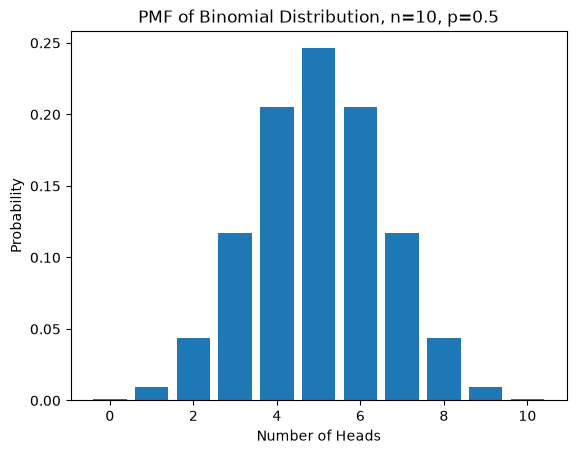

In [26]:
import matplotlib.pyplot as plt

n=10 #numbers of flips
p=0.5

probabile_heads=[0,1,2,3,4,5,6,7,8,9,10]

pmf_vals = stats.binom.pmf(probabile_heads, n, p)
print(pmf_vals)

plt.bar(probabile_heads, pmf_vals)
plt.xlabel('Number of Heads')
plt.ylabel('Probability')
plt.title(f'PMF of Binomial Distribution, n={n}, p={p}')
plt.show()


<font size="4"> 

**Try it yourself!** Copy the plotting code above into the cell below, change `p` to `0.7` (a coin biased toward heads), and re-run it. Which way does the peak of the chart shift?

In [ ]:
# Write your own code here:
# Graph the binomial distribution for a biased coin with p = 0.7.



### Recapping our use of `scipy`: We saw that using specialized functions has a significant performance benefit. The point is not that you need to memorize functions from the `scipy` library. It is that you should be aware of these functions and know to look for them rather than doing a calculation on your own.

## <span style="color:darkblue"> IV. `numpy` arrays </span>

<font size="4"> 


- We saw that the "+" operator *concatenates* (or combines) two lists. 

- What if we actually want to add the elements in two sequences entry by entry? We can do this using **NumPy** arrays.

- The NumPy library (NUMerical PYthon) is a library that is widely used for numerical computations (computations with floating-point numbers)

- It comes with a bunch of mathematical functions - **it basically makes the "math" library obsolete**

- It also comes with its own sequence object, the NumPy array

In [29]:
# import the library. "np" is the standard nickname
import numpy as np

# The most common way to create a Numpy array is to convert a list 
# into a numpy array.

list_of_numbers = [5.6, 2.9, 9.7, -10, 0, 3]

array_of_numbers = np.array(list_of_numbers)

print(type(array_of_numbers))
print(array_of_numbers)
display(array_of_numbers)

<class 'numpy.ndarray'>
[  5.6   2.9   9.7 -10.    0.    3. ]


array([  5.6,   2.9,   9.7, -10. ,   0. ,   3. ])

In [30]:
# import the library. "np" is the standard nickname
import numpy as np

# The most common way to create a Numpy array is to convert a list 
# into a numpy array.

list_of_numbers = [5.6, 2.9, 9.7, -10, 0, 3]

array_of_numbers = np.array(list_of_numbers)

print(type(array_of_numbers))
print(array_of_numbers)
display(array_of_numbers)

<class 'numpy.ndarray'>
[  5.6   2.9   9.7 -10.    0.    3. ]


array([  5.6,   2.9,   9.7, -10. ,   0. ,   3. ])

<font size = "4">

- NumPy arrays are primarily useful for storing numbers. You *can* make a NumPy array with strings or other objects, but that is unusual.

- One of the benefits of NumPy is that all operations on arrays are numerical, unlike lists

In [31]:
list_1 = [2, 3, 5, 11]
list_2 = [1, -4, 2, 0]

# The "+" operation concatenates the lists
print(list_1 + list_2)

[2, 3, 5, 11, 1, -4, 2, 0]


In [32]:
array_1 = np.array([2, 3, 5, 11])
array_2 = np.array([1, -4, 2, 0])

# The "+" operation adds the elements of the two arrays together
print(array_1 + array_2)

[ 3 -1  7 11]


### The + operation performs element-by-element addition between two arrays of the **same size**. Mathematically, we view NumPy arrays as *vectors*, specifically column vectors.

$\text{An example where both arrays/vectors have 4 elements}$

$ a + b = \begin{pmatrix} a_1 \\ a_2 \\ a_3 \\ a_4 \end{pmatrix} +
          \begin{pmatrix} b_1 \\ b_2 \\ b_3 \\ b_4 \end{pmatrix} =
          \begin{pmatrix} a_1 + b_1 \\ a_2 + b_2 \\ a_3 + b_3 \\ a_4 + b_4 \end{pmatrix}$


### You can also use the "+" operator with a Numpy Array and a single number

$\text{For example:}$

$ a + 2 = \begin{pmatrix} a_1 \\ a_2 \\ a_3\end{pmatrix} + 2 = \begin{pmatrix} a_1 + 2 \\ a_2 + 2 \\ a_3 + 2\end{pmatrix}$

In [33]:
# example

a = np.array([3, 11, -2.2])
print(a + 2)

[ 5.  13.  -0.2]


### We'll see below that this definition extends to other operations like subtraction, multiplication, division, exponentiation.

## <span style="color:darkblue"> V. Mathematical Constants and Operations </span>

<font size = "3">

The usual mathematical operations - addition, subtraction, multiplication, division, and exponentiation are standard in Python.

In the cell below, we compute
- $3.2 + 1.7 = 4.9$

- $5 - 11 = -6$

- $4 \cdot 3 = 12$

- $\dfrac{1}{7} \approx 0.142857$

- $2^5 = 32$

In [34]:
print(3.2 + 1.7)
print(5 - 11)
print(4 * 3)
print(1 / 7)
print(2**5)

4.9
-6
12
0.14285714285714285
32


<font size = "4">

**Be careful with order of operations** (also known as operator precedence)

How should we calculate the following in Python?
$$ \frac{13 + 8}{3} = \frac{21}{3} = 7$$

In [35]:
right_answer = (13 + 8) / 3
wrong_answer = 13 + 8 / 3
print(right_answer)
print(wrong_answer)

7.0
15.666666666666666


<font size = "4">

Numpy comes with a wide variety of mathematical constants and functions

Below, we will evaluate the following functions:

$$ \ln(x),\  \mathrm{e}^x,\  \sin(x),\  \cos(x),\  \sqrt{x}$$

In [36]:
# log(x) computes the logarithm with base "e" (Euler's number)
    # in high school you might have called this ln(x)

# exp(x) compute Euler's number raised to the power of "x"

# sin(x) computes the sine of x (in radians)

# cos(x) computes the cosine of x (in radians)

# In this example, we're substituting x = 2

print(np.log(2))
print(np.exp(2))
print(np.sin(2))
print(np.cos(2))
print(np.sqrt(2))

0.6931471805599453
7.38905609893065
0.9092974268256817
-0.4161468365471424
1.4142135623730951


In [37]:
# use variable instead of "2" when using the function

my_var = 2

print(np.log(my_var))
print(np.exp(my_var))
print(np.sin(my_var))
print(np.cos(my_var))
print(np.sqrt(my_var))

0.6931471805599453
7.38905609893065
0.9092974268256817
-0.4161468365471424
1.4142135623730951


In [38]:
# NumPy also comes with built-in constants like
print(np.pi) # pi = circle's circumference/circle's diameter

print(np.e) # Euler's number = limit of (1 + 1/n)^n as n goes to infinity

print(np.exp(1)) # another way to calculate Euler's number

3.141592653589793
2.718281828459045
2.718281828459045


## <span style="color:darkblue"> VI. Plotting functions using NumPy arrays </span>

<font size = "4">

- NumPy arrays are very convenient for plotting functions, because you can use them within mathematical expressions as if they were numbers

- For example, suppose we want to create a scatter plot of the function 

$$ f(x) = x^3 - 2x + \frac{1}{2} $$
&ensp; &ensp; &ensp; at equally spaced points over the interval $-1.5 \leq x \leq 1.5$.

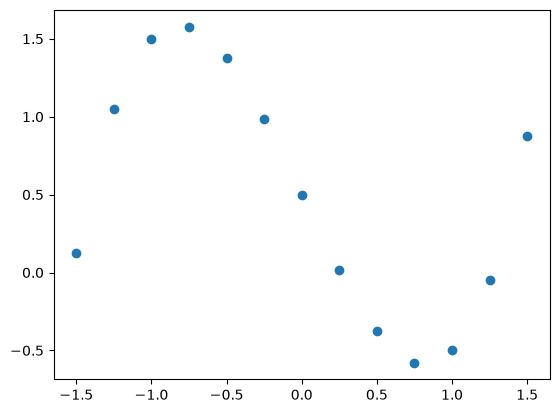

In [39]:
# Create list of equally spaced points from -1.5 to 1.5
# We'll choose points 0.25 apart
x_vals = [-1.5, -1.25, -1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1, 1.25, 1.5]

# Convert to numpy array
x_vals = np.array(x_vals)

# Create new numpy array with the function evaluated at the same points
y_vals = x_vals**3 - 2*x_vals + 0.5

# Use plt.scatter to create scatter plot
plt.scatter(x = x_vals, y = y_vals)
plt.show()

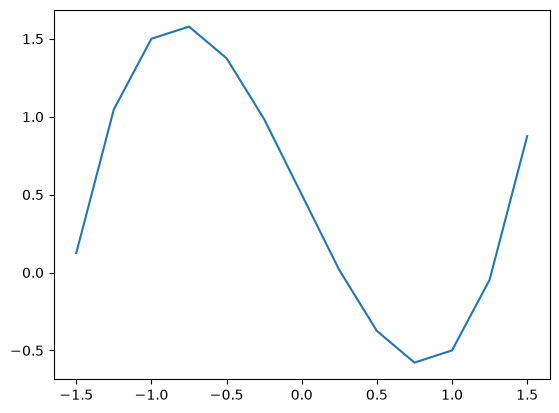

In [42]:
x_vals = [-1.5, -1.25, -1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1, 1.25, 1.5]

# Convert to numpy array
x_vals = np.array(x_vals)

# Create new numpy array with the function evaluated at the same points
y_vals = x_vals**3 - 2*x_vals + 0.5

# Use plt.scatter to create scatter plot
plt.plot(x_vals, y_vals)
plt.show()

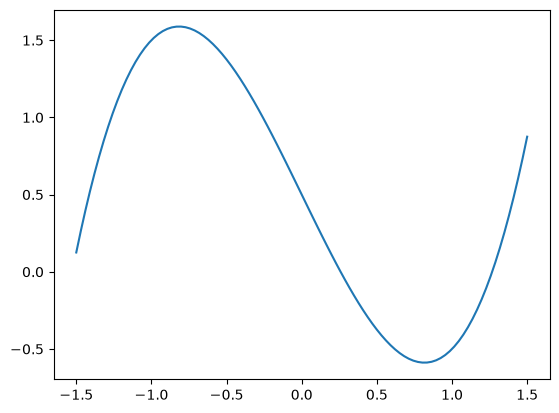

In [43]:
x_vals = np.linspace(-1.5, 1.5, 100) # 100 points from -1.5 to 1.5
y_vals = x_vals**3 - 2*x_vals + 0.5

# Use plt.scatter to create scatter plot
plt.plot(x_vals, y_vals)
plt.show()

<font size = "4">

- You can also use Numpy arrays together with Numpy mathematical functions

- For example, to make a scatter plot of the function

$$ g(t) = \mathrm{e}^{t^2} - \sqrt{t} + 1$$

&ensp; &ensp; &ensp; at equally spaced points over the interval $0 \leq t \leq 0.5$, we can do:

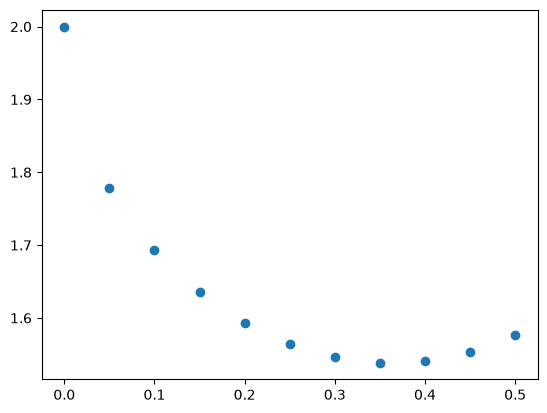

In [40]:
# convert list to numpy array right away
t_vals = np.array( [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5] )

# Evaluate function and create new array 
g_of_t = np.exp(t_vals**2) - np.sqrt(t_vals) + 1

# Use plt.scatter to create scatter plot
plt.scatter(x = t_vals, y = g_of_t)
plt.show()

# <span style="color:red; font-size:30px"> Exercises</span>

#### **1)** In the cell below, a list "days" is defined containing the seven days of the week. You want to schedule office hours by appointment with your professor. The list "free_days" contains the days that your professor is available.

<font size = "4">

- Randomly select one of the days of the week in the list "days" using the `random` library. Assign it to a variable called "proposed_day". 

- Create a Boolean variable called "is_free" that has the value `True` if the professor is available on the randomly selected day, and `False` otherwise.

- Print the values of "proposed_day" and "is_free" to the screen.

In [44]:
days = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

free_days = ["Monday", "Thursday", "Friday"]

# Your code here
proposed_day=random.choice(days)
is_free=proposed_day in free_days
print(proposed_day)
print(is_free)

Thursday
True


#### **2)** Imagine flipping a coin repeatedly until we get 10 heads (in total, not in a row). How many tails will you see before seeing the 10th head?

<font size = "4">

The **negative binomial distribution** describes exactly this. Given

- `n` = the number of heads needed to stop the experiment, and
- `p` = the probability of heads on a single flip,

it tells us the probability of getting each possible number of tails before the experiment ends (0 tails, 1 tail, 2 tails, ... ).

<font size="4"> 

The probability of exactly `k` tails before seeing `n` heads is

$$P(k \text{ tails}) = \frac{(k+n-1)!}{k!\,(n-1)!}\, p^{k}\,(1-p)^{n}$$

Use the scipy function `scipy.stats.binom` to plot the probability mass function over the range $k=0, 1, 2, ..., 9, 10$ when we stop after flipping $n=10$ heads of a fair coin (so $p = 0.5$).


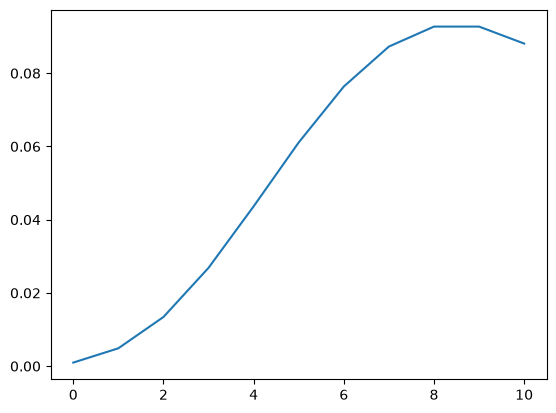

In [54]:
# Your code here
import scipy.stats
n=10
p=0.5

prob=scipy.stats.nbinom(n, p)

k=range(0,11)
plt.plot(k, prob.pmf(k))
plt.show()

#### **3a)** How should we calculate the following in Python, using the numbers `27`, `12`, and `3`?

$$ \frac{27}{12 - 3} = \frac{27}{9} = 3$$

#### Compute this expression in the cell below

In [50]:
# Calculate the expression above using the numbers 27, 12, 3
# Print the value -- you should get the number 3
print((27)/(12-3))

3.0


#### **3b)** How should we calculate the following in Python, using the numbers `5`, `3`, and `2`?

$$ (5 + 3)\cdot 2 = 8 \cdot 2 = 16$$

#### Compute this expression in the cell below

In [51]:
# Calculate the expression above using the numbers 5, 3, 2
# Print the value -- you should get the number 16
print((5+3)*2)


16


#### **3c)** How should we calculate the following in Python, using the numbers `5`, `4`, `3`, and `2`?

$$ 5\cdot 3 + 2\cdot 4 = 15 + 8 = 23$$

#### Compute this expression in the cell below. Are parentheses necessary for this expression?

In [52]:
# Calculate the expression above using the numbers 5, 4, 3, 2
# Print the value -- you should get the number 23
# CHECK: Are parentheses necessary for this expression?

print(5*3+2*4)

23


#### **3d)** How should we calculate the following in Python, using the numbers `5`, `4`, `3`, and `2`?

$$ \frac{(5 + 3)\cdot 2}{4} = \frac{16}{4} = 4$$

#### Compute this expression in the cell below. Are two pairs of parentheses necessary for this expression?

In [53]:
# Calculate the expression above using the numbers 5, 4, 3, 2
# Print the value -- you should get the number 4
# CHECK: Are *two pairs* of parentheses actually necessary?

print((5+3)*2/4)

4.0


#### **4)** Using NumPy, do the following:

<font size = "4">

- Define a variable $x = 0.5$

- Compute the value of $\pi x^2$ (ensure it prints to the screen)

- Compute the value of $\dfrac{1}{\sqrt{2\pi}}\mathrm{e}^{-x^2}$ (print to the screen)

- Compute the value of $\ln\big(\dfrac{2x + 1}{x + 2}\big)$ (print to the screen)

**Note**: Feel free to break up the computation into steps and define intermediate variables in order to make the code cleaner.

For example, for the final expression, you might find it convenient to create an additional variable $z = \dfrac{2x + 1}{x + 2}$. Or even $u = 2x + 1$ and $v = x + 2$

In [60]:
# your code here

x=0.5
a=np.pi*x**2
print(a)
b=1/np.sqrt(2*np.pi)*np.exp(-x**2)
print(b)
c=(2*x+1)/(x+2)
print(c)

0.7853981633974483
0.3106965603769278
0.8


#### **5)** The code cell below defines two vectors

$a = \begin{pmatrix} a_1\\a_2\\a_3\end{pmatrix},\quad b = \begin{pmatrix} b_1\\b_2\\b_3\end{pmatrix}$

#### In one line of code each, define the following vectors:
$c = \begin{pmatrix} a_1\cdot b_1\\ a_2 \cdot b_2 \\ a_3 \cdot b_3 \end{pmatrix}, \quad d = \begin{pmatrix} 5 - a_1\\ 5 - a_2 \\ 5 - a_3 \end{pmatrix},\quad e = \begin{pmatrix} (a_1 - b_1)/2 \\ (a_2 - b_2)/2 \\ (a_3 - b_3)/2\end{pmatrix}$

$f = \begin{pmatrix} b_1^{a_1}\\ b_2^{a_2} \\ b_3^{a_3} \end{pmatrix},\quad g = \begin{pmatrix} 2^{a_1}\\ 2^{a_2} \\ 2^{a_3}\end{pmatrix},\quad h = \begin{pmatrix} \mathrm{e}^{a_1 + b_1} \\ \mathrm{e}^{a_2 + b_2} \\ \mathrm{e}^{a_3 + b_3} \end{pmatrix}$

#### (Try to extend the vector operations you saw above)

In [58]:
a = np.array([2, 1.2, 3.4])
b = np.array([2.2, -3, 10.01])

# fill in the correct code below
c = a*b
d = 5-a
e = (a-b)/2
f = b**a
g = 2**a
h = np.exp(a+b)

/var/folders/rr/sv5mmf_12pl3_4jd28mkfn4h0000gn/T/ipykernel_18668/3801238557.py:8: RuntimeWarning: invalid value encountered in power
  f = b**a


#### **6)** In the cell below, two arrays are created:

$a = \begin{pmatrix} a_1\\a_2\\a_3\\a_4\end{pmatrix},\quad b = \begin{pmatrix} b_1\\b_2\\b_3\\b_4\end{pmatrix}$

### Define a new array

$c = \begin{pmatrix} a_1/b_1\\ a_2/b_2\\ a_3/b_3\\a_4/b_4\end{pmatrix}$

### and print its value to the screen. What do you see? Can you explain the reason for it?


In [ ]:
a = np.array([0, 1.0, np.pi, np.cos(np.pi/12)])
b = np.array([0, 2.0, 4, 0])

# your code here



#### **7)** Using NumPy arrays, create a scatter plot of the function

$$q(x) = \sin(\pi x) + 1$$

#### at a set of points in the interval $0 \leq x \leq 2$. (You are free to choose which points are actually used)

In [ ]:
# your code here 



#### **8)** Using NumPy arrays, create a scatter plot of the function $f(g(t))$, where

$$ f(x) = x^2 - 5x + 2 $$

$$ g(t) = \sin(t + 3) $$

#### at a set of points in the interval $2\pi \leq x \leq 4\pi$. (You are free to choose which points are actually used)

In [ ]:
# your code here 

